In [115]:
import pandas as pd

# CSV 파일 불러오기
df1 = pd.read_csv("./Result/임도별_대표_임상.csv",  usecols=["FRRD_NM", "dominant_FRTP_CD"])
df2 = pd.read_csv("./Result/임도별_평균_경사도.csv")
df3 = pd.read_csv("./Result/임도별_평균_산사태위험도.csv", usecols=['FRRD_NM', 'mean'])
df4 = pd.read_csv("./Result/임도별_대표_토양.csv", usecols=['FRRD_NM', 'SLTP_CODE'])
df5 = pd.read_csv("./Result/임도별_평균_강수량.csv", usecols=['FRRD_NM', 'mean'])

# 공통 열 이름 확인
print(df1.columns)
print(df2.columns)
print(df3.columns)
print(df4.columns)
print(df5.columns)

Index(['FRRD_NM', 'dominant_FRTP_CD'], dtype='object')
Index(['FRRD_NM', 'slope_mean'], dtype='object')
Index(['FRRD_NM', 'mean'], dtype='object')
Index(['FRRD_NM', 'SLTP_CODE'], dtype='object')
Index(['FRRD_NM', 'mean'], dtype='object')


In [116]:
merged_df = pd.merge(df1, df2, on="FRRD_NM", how="inner").merge(df3, on="FRRD_NM", how="inner").merge(df4, on="FRRD_NM", how="inner").merge(df5, on="FRRD_NM", how="inner")

In [117]:
merged_df

,FRRD_NM,dominant_FRTP_CD,slope_mean,mean_x,SLTP_CODE,mean_y
0,100번 속곡,2.0,27.915866,2.592391,1,43.299247
1,101번 상원,1.0,24.241932,2.936599,13,47.409664
2,102번 본신,1.0,23.534046,2.610390,2,45.523984
3,103번 수하,2.0,22.436641,3.516529,14,46.527605
4,104번 무창,1.0,17.772672,3.300000,14,45.945775
...,...,...,...,...,...,...
421,황새골(2),1.0,24.145713,2.805000,2,52.221015
422,황악산2,1.0,26.062860,3.224359,2,48.855426
423,황점,1.0,23.247219,3.041623,2,52.325902
424,횡악산1,1.0,27.162142,2.813187,2,48.894914


In [118]:
X = merged_df[['SLTP_CODE', 'mean_x', 'dominant_FRTP_CD', 'slope_mean', 'mean_y']]

In [47]:
X

,SLTP_CODE,mean_x,dominant_FRTP_CD,slope_mean,mean_y
0,1,2.592391,2.0,27.915866,43.299247
1,13,2.936599,1.0,24.241932,47.409664
2,2,2.610390,1.0,23.534046,45.523984
3,14,3.516529,2.0,22.436641,46.527605
4,14,3.300000,1.0,17.772672,45.945775
...,...,...,...,...,...
421,2,2.805000,1.0,24.145713,52.221015
422,2,3.224359,1.0,26.062860,48.855426
423,2,3.041623,1.0,23.247219,52.325902
424,2,2.813187,1.0,27.162142,48.894914


In [48]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

cols_to_scale = ['mean_x', 'slope_mean', 'mean_y']
scaler = StandardScaler()
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

C:\Users\user\AppData\Local\Temp\ipykernel_3944\1812548423.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])


In [49]:
X.head()

,SLTP_CODE,mean_x,dominant_FRTP_CD,slope_mean,mean_y
0,1,-2.014805,2.0,1.384960,-1.381819
1,13,-0.973129,1.0,0.629990,-0.205307
2,2,-1.960337,1.0,0.484524,-0.745039
3,14,0.781909,2.0,0.259014,-0.457776
4,14,0.126629,1.0,-0.699401,-0.624311


In [78]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=7)

kmeans.fit(X)

KMeans(n_clusters=3, random_state=7)

In [79]:
print(kmeans.labels_)

[0 2 0 2 2 2 2 2 0 2 2 0 0 2 0 2 0 2 2 2 2 0 0 0 0 0 2 2 2 0 0 2 0 0 2 2 2
 2 0 0 2 2 0 2 0 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 0 2 2 0 2 0 2
 2 2 2 0 0 0 2 2 2 2 2 2 0 2 2 2 2 2 0 0 2 2 2 0 0 2 2 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0
 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 2 2 0 0 0 0 0 0 0 2
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0]


In [80]:
from sklearn.metrics import silhouette_score, silhouette_samples

silhouette_avg = silhouette_score(X, kmeans.labels_)
print(silhouette_avg)

0.8017681104570454


In [81]:
merged_df

,FRRD_NM,dominant_FRTP_CD,slope_mean,mean_x,SLTP_CODE,mean_y,cluster
0,100번 속곡,2.0,27.915866,2.592391,1,43.299247,0
1,101번 상원,1.0,24.241932,2.936599,13,47.409664,0
2,102번 본신,1.0,23.534046,2.610390,2,45.523984,0
3,103번 수하,2.0,22.436641,3.516529,14,46.527605,0
4,104번 무창,1.0,17.772672,3.300000,14,45.945775,0
...,...,...,...,...,...,...,...
421,황새골(2),1.0,24.145713,2.805000,2,52.221015,0
422,황악산2,1.0,26.062860,3.224359,2,48.855426,0
423,황점,1.0,23.247219,3.041623,2,52.325902,0
424,횡악산1,1.0,27.162142,2.813187,2,48.894914,0


In [82]:
merged_df['cluster'] = kmeans.labels_

In [83]:
merged_df

,FRRD_NM,dominant_FRTP_CD,slope_mean,mean_x,SLTP_CODE,mean_y,cluster
0,100번 속곡,2.0,27.915866,2.592391,1,43.299247,0
1,101번 상원,1.0,24.241932,2.936599,13,47.409664,2
2,102번 본신,1.0,23.534046,2.610390,2,45.523984,0
3,103번 수하,2.0,22.436641,3.516529,14,46.527605,2
4,104번 무창,1.0,17.772672,3.300000,14,45.945775,2
...,...,...,...,...,...,...,...
421,황새골(2),1.0,24.145713,2.805000,2,52.221015,0
422,황악산2,1.0,26.062860,3.224359,2,48.855426,0
423,황점,1.0,23.247219,3.041623,2,52.325902,0
424,횡악산1,1.0,27.162142,2.813187,2,48.894914,0


In [84]:
# 그룹별 평균
mean_df = merged_df.groupby('cluster')[['slope_mean', 'mean_x', 'mean_y']].mean()

# 그룹별 최빈값 함수 정의
mode_df = merged_df.groupby('cluster')[['dominant_FRTP_CD', 'SLTP_CODE']].agg(lambda x: x.mode().iloc[0])

# 평균과 최빈값 결합
summary = pd.concat([mean_df, mode_df], axis=1)

# 결과 출력
print(summary)


         slope_mean    mean_x     mean_y  dominant_FRTP_CD  SLTP_CODE
cluster                                                              
0         21.445471  3.227068  48.780238               1.0          2
1         23.279448  3.262682  49.789808               1.0         99
2         20.266886  3.355863  46.022116               1.0         14


In [85]:
merged_df_cluster = merged_df[['FRRD_NM', 'cluster']]

In [86]:
merged_df_cluster

,FRRD_NM,cluster
0,100번 속곡,0
1,101번 상원,2
2,102번 본신,0
3,103번 수하,2
4,104번 무창,2
...,...,...
421,황새골(2),0
422,황악산2,0
423,황점,0
424,횡악산1,0


In [96]:
import geopandas as gpd

# Shapefile 읽기 (.shp 파일만 지정하면 나머지는 자동으로 함께 불러옴)
gdf = gpd.read_file("../DATA/버퍼데이터10.shp")

# 상위 5개 확인
gdf.head()

,HSTR_MNNMB,ETC_PCMTT,FRRD_NM,FRRD_FCLT,FRRD_FCLTD,FRRD_ESTBL,FRRD_FCLTW,FRRD_DV_I,FRRD_DV_B,FRRD_INSTT,...,RBP_Y,REP_X,REP_Y,MAP_LABEL,FRRD_THM,FR_TH_NM,FR_TH_DV,FR_TH_YR,Shape_Leng,geometry
0,0.0,None,11번 월매,None,1.91,1990,3.0,1,1,43,...,403023.691956,380682.836268,400022.43799,1990_11번 월매,None,None,1,None,5722.138787,"POLYGON ((1136433.105 1802272.466, 1136430.978..."
1,0.0,None,11번 월매,None,1.91,1990,3.0,1,1,43,...,403023.691956,380682.836268,400022.43799,1990_11번 월매,None,None,1,None,5722.138787,"POLYGON ((1136401.552 1802182.27, 1136401.346 ..."
2,0.0,None,11번 월매,None,1.91,1990,3.0,1,1,43,...,403023.691956,380682.836268,400022.43799,1990_11번 월매,None,None,1,None,5722.138787,"POLYGON ((1136340.592 1802108.416, 1136340.125..."
3,0.0,None,11번 월매,None,1.91,1990,3.0,1,1,43,...,403023.691956,380682.836268,400022.43799,1990_11번 월매,None,None,1,None,5722.138787,"POLYGON ((1136246.304 1802056.069, 1136241.031..."
4,0.0,None,11번 월매,None,1.91,1990,3.0,1,1,43,...,403023.691956,380682.836268,400022.43799,1990_11번 월매,None,None,1,None,5722.138787,"POLYGON ((1136158.134 1802016.175, 1136154.073..."


In [98]:
gdf_clustered = gdf.merge(merged_df_cluster, on="FRRD_NM", how="left")

# 결과 확인
gdf_clustered.head()

,HSTR_MNNMB,ETC_PCMTT,FRRD_NM,FRRD_FCLT,FRRD_FCLTD,FRRD_ESTBL,FRRD_FCLTW,FRRD_DV_I,FRRD_DV_B,FRRD_INSTT,...,REP_X,REP_Y,MAP_LABEL,FRRD_THM,FR_TH_NM,FR_TH_DV,FR_TH_YR,Shape_Leng,geometry,cluster
0,0.0,None,11번 월매,None,1.91,1990,3.0,1,1,43,...,380682.836268,400022.43799,1990_11번 월매,None,None,1,None,5722.138787,"POLYGON ((1136433.105 1802272.466, 1136430.978...",0.0
1,0.0,None,11번 월매,None,1.91,1990,3.0,1,1,43,...,380682.836268,400022.43799,1990_11번 월매,None,None,1,None,5722.138787,"POLYGON ((1136401.552 1802182.27, 1136401.346 ...",0.0
2,0.0,None,11번 월매,None,1.91,1990,3.0,1,1,43,...,380682.836268,400022.43799,1990_11번 월매,None,None,1,None,5722.138787,"POLYGON ((1136340.592 1802108.416, 1136340.125...",0.0
3,0.0,None,11번 월매,None,1.91,1990,3.0,1,1,43,...,380682.836268,400022.43799,1990_11번 월매,None,None,1,None,5722.138787,"POLYGON ((1136246.304 1802056.069, 1136241.031...",0.0
4,0.0,None,11번 월매,None,1.91,1990,3.0,1,1,43,...,380682.836268,400022.43799,1990_11번 월매,None,None,1,None,5722.138787,"POLYGON ((1136158.134 1802016.175, 1136154.073...",0.0


In [99]:
nan_count = gdf_clustered['cluster'].isna().sum()
print(f"NaN 개수: {nan_count}")

NaN 개수: 22


In [102]:
gdf_clustered[gdf_clustered['cluster'].isna()]

,HSTR_MNNMB,ETC_PCMTT,FRRD_NM,FRRD_FCLT,FRRD_FCLTD,FRRD_ESTBL,FRRD_FCLTW,FRRD_DV_I,FRRD_DV_B,FRRD_INSTT,...,REP_X,REP_Y,MAP_LABEL,FRRD_THM,FR_TH_NM,FR_TH_DV,FR_TH_YR,Shape_Leng,geometry,cluster
8049,0.0,None,광산골,None,0.68,2006,4.0,1,1,43,...,398258.754057,495650.146730,2006_광산골,None,None,1,None,640.249720,"POLYGON ((1153323.561 1894693.429, 1153323.79 ...",NaN
8050,0.0,None,광산골,None,0.68,2006,4.0,1,1,43,...,398258.754057,495650.146730,2006_광산골,None,None,1,None,640.249720,"POLYGON ((1153337.541 1894764.946, 1153337.983...",NaN
8051,0.0,None,광산골,None,0.68,2006,4.0,1,1,43,...,398258.754057,495650.146730,2006_광산골,None,None,1,None,640.249720,"POLYGON ((1153376.486 1894853.233, 1153377.246...",NaN
8052,0.0,None,광산골,None,0.68,2006,4.0,1,1,43,...,398258.754057,495650.146730,2006_광산골,None,None,1,None,640.249720,"POLYGON ((1153482.648 1894845.26, 1153483.404 ...",NaN
8053,0.0,None,광산골,None,0.68,2006,4.0,1,1,43,...,398258.754057,495650.146730,2006_광산골,None,None,1,None,640.249720,"POLYGON ((1153518.867 1894752.089, 1153515.988...",NaN
8054,0.0,None,광산골,None,0.68,2006,4.0,1,1,43,...,398258.754057,495650.146730,2006_광산골,None,None,1,None,640.249720,"POLYGON ((1153613.043 1894757.519, 1153613.555...",NaN
8055,0.0,None,광산골,None,0.68,2006,4.0,1,1,43,...,398258.754057,495650.146730,2006_광산골,None,None,1,None,640.249720,"POLYGON ((1153687.326 1894803.983, 1153688.013...",NaN
13797,0.0,None,소광(광산골),None,1.10,2022,5.0,1,3,43,...,398736.418559,495816.257957,2022_소광(광산골),None,None,3,None,1366.431699,"POLYGON ((1153562.505 1894776.848, 1153563.649...",NaN
13798,0.0,None,소광(광산골),None,1.10,2022,5.0,1,3,43,...,398736.418559,495816.257957,2022_소광(광산골),None,None,3,None,1366.431699,"POLYGON ((1153613.57 1894841.377, 1153611.438 ...",NaN
13799,0.0,None,소광(광산골),None,1.10,2022,5.0,1,3,43,...,398736.418559,495816.257957,2022_소광(광산골),None,None,3,None,1366.431699,"POLYGON ((1153610.631 1894905.764, 1153610.026...",NaN


In [103]:
gdf_clustered = gdf_clustered.dropna(subset=['cluster']).reset_index(drop=True)


In [105]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 기호 깨짐 방지

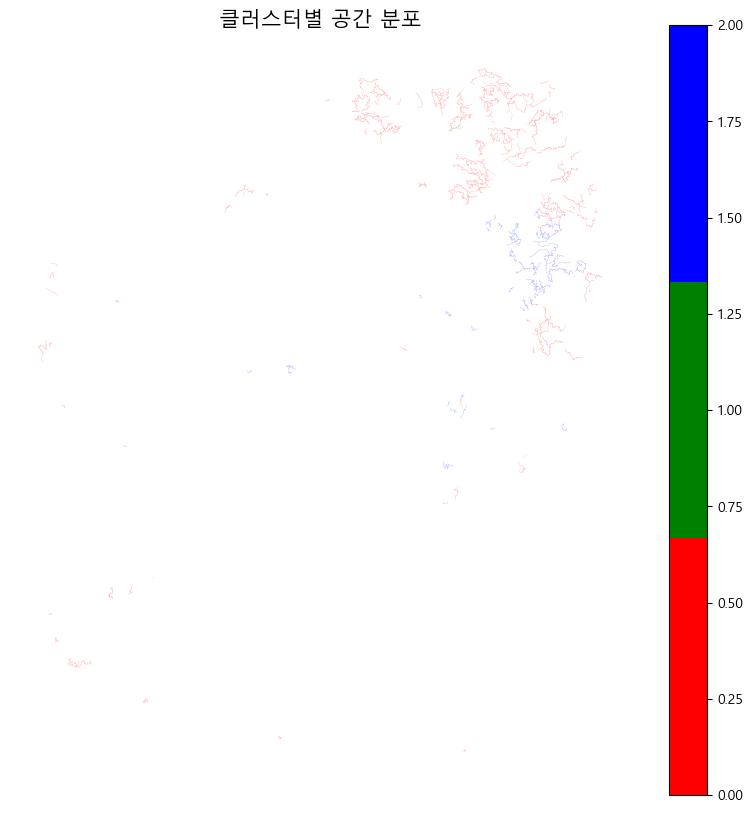

In [111]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 클러스터 색상 목록 (3개 클러스터)
colors = ['red', 'green', 'blue']
cmap = ListedColormap(colors)

# 라인에 색상 적용
fig, ax = plt.subplots(figsize=(10, 10))
gdf_clustered.plot(column='cluster', cmap=cmap, legend=True, ax=ax, linewidth=1)

plt.title("클러스터별 공간 분포", fontsize=15)
plt.axis('off')
plt.show()
